# Chapter 20 — Fatigue and Cyclic Loading
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 20 — Fatigue and Cyclic Loading.

Most structural failures in service do not occur under a single overload — they accumulate slowly, cycle by cycle, from loads well below the static yield strength. Fatigue is the mechanism by which repeated stress cycling initiates and propagates cracks until catastrophic fracture occurs, and it is responsible for the majority of mechanical failures in aircraft, vehicles, and rotating machinery. Understanding fatigue is inseparable from understanding strain measurement, because strain gages are the primary tool for quantifying the cyclic stress history that drives damage accumulation.

This notebook covers two foundational tools of fatigue analysis: the S-N curve (relating stress amplitude to cycles to failure) and Miner's linear damage rule (summing fractional damage across multiple amplitude levels). Together they allow an engineer to predict the remaining life of a component from a measured load spectrum — the output of a strain gage data acquisition campaign.

**This notebook demonstrates:**
0. Wöhler's own rotating-bending data (1870), re-plotted in MPa
1. The S-N curve (Basquin's law) with endurance limit — stress amplitude vs. cycles to failure
2. Miner's rule cumulative damage calculation for a four-level load spectrum

In [1]:
# Colab setup — uncomment to install dependencies:
# !pip install numpy matplotlib

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figure output directory. Do NOT change this path — the book includes these exact files.
OUT_DIR = Path("../src/media/ch20")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
### Shared constants and helper functions

Both sections below rest on the same material model — Basquin's power law, $\sigma_a = \sigma_f'\,(2N_f)^b$ — so we define the material constants and two small helper functions once and reuse them. `basquin_stress` maps a life (in cycles) to the stress amplitude that produces it; `cycles_to_failure` inverts the law to predict life from a measured stress amplitude, which is exactly what a strain gage campaign supplies.

In [2]:
# Material constants for the steel of the chapter's worked examples (UTS 540 MPa).
# The two Basquin constants reproduce the usual textbook estimate for steel,
# 0.9*UTS at 10^3 cycles and 0.5*UTS at 10^6 cycles (486 and 270 MPa), so the
# sloping line meets the endurance limit exactly at the knee, 10^6 cycles.
SIGMA_UTS = 540.0           # MPa — ultimate tensile strength
ENDURANCE_FRACTION = 0.5    # endurance limit ~= 0.5 * UTS (common steel rule of thumb)
B_EXPONENT = np.log10(0.5 / 0.9) / 3.0                        # ~ -0.0851
SIGMA_F_PRIME = 0.9 * SIGMA_UTS * (2.0 * 1e3) ** (-B_EXPONENT)  # MPa, ~ 928


def basquin_stress(cycles, sigma_f_prime=SIGMA_F_PRIME, b=B_EXPONENT):
    """Stress amplitude (MPa) for a given life, via Basquin's law.

    sigma_a = sigma_f' * (2 * Nf) ** b, where 2*Nf is reversals to failure.
    """
    return sigma_f_prime * (2.0 * cycles) ** b


def cycles_to_failure(sigma_a, sigma_f_prime=SIGMA_F_PRIME, b=B_EXPONENT):
    """Cycles to failure Nf at a stress amplitude, inverting Basquin's law.

    Solving sigma_a = sigma_f' (2 Nf)^b gives Nf = 0.5 * (sigma_a / sigma_f') ** (1 / b).
    """
    return 0.5 * (sigma_a / sigma_f_prime) ** (1.0 / b)

---
## 0 — Wöhler's own S-N data (1870)

Before any model, the data that started it. In 1870 August Wöhler published the results of the rotating-bending tests he had run in the central workshop of the Lower Silesian-Märkisch Railway at Frankfurt an der Oder (*Zeitschrift für Bauwesen* 20, 73–106, Table I). The bars were cut cold from wrought-iron axles that the Phoenix company had supplied in 1857. Each bar was pressed into the end of a rotating shaft, the way an axle is pressed into a wheel hub, and loaded at its free end, so every revolution took the outer fiber from tension to compression and back. Wöhler tabulated the largest fiber stress in Zentner per Prussian square inch and the revolutions to fracture; he never drew the curve.

Three bar shapes are plotted. In the first, the reduced shank meets the hub section through a slender fillet (*schlanke Hohlkehle*). The other two have a sharp shoulder (*scharf abgesetzt*): (a) at the face of the hub, and (b) on a collar standing out beyond it, followed by a taper.

The stress conversion uses the 50 kg Zollzentner (standard in Prussia from 1858) and the 26.15 mm Prussian inch, so 1 Ctr per square inch is about 0.717 MPa. Bars that had not broken when the test was stopped (run-outs) are drawn as open markers with an arrow.

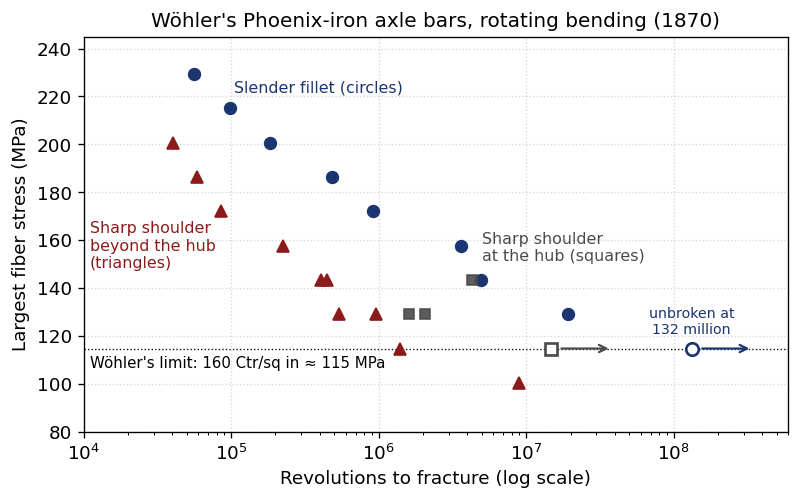

fillet 229 MPa/56,430 215 MPa/99,000 201 MPa/183,145 186 MPa/479,490 172 MPa/909,810 158 MPa/3,632,588 143 MPa/4,917,992 129 MPa/19,186,791
shoulder b 201 MPa/40,274 186 MPa/58,449 172 MPa/85,576 158 MPa/224,111 143 MPa/445,377 143 MPa/409,860 129 MPa/956,803 129 MPa/535,302 115 MPa/1,386,072 100 MPa/8,999,942
1 Ctr/sq in = 0.7168 MPa


In [3]:
# Wöhler (1870), Zeitschrift für Bauwesen 20, Table I: bars cut from Phoenix
# wrought-iron axles (1857), rotating bending. Stress in Zentner per Prussian
# square inch (Ctr/sq in), life in revolutions to fracture.
CTR_PER_SQIN_TO_MPA = 50.0 * 9.80665 / (26.1545 ** 2)    # ~0.717 MPa

fillet = [(320, 56_430), (300, 99_000), (280, 183_145), (260, 479_490),
          (240, 909_810), (220, 3_632_588), (200, 4_917_992), (180, 19_186_791)]
fillet_runout = [(160, 132_250_000)]           # No. 9: still running
shoulder_a = [(200, 4_315_359), (180, 1_603_570), (180, 2_063_760)]
shoulder_a_runout = [(160, 14_695_000)]        # No. 13: taken out of service
shoulder_b = [(280, 40_274), (260, 58_449), (240, 85_576), (220, 224_111),
              (200, 445_377), (200, 409_860), (180, 956_803), (180, 535_302),
              (160, 1_386_072), (140, 8_999_942)]


def mpa(rows):
    s = np.array([r[0] for r in rows], float) * CTR_PER_SQIN_TO_MPA
    n = np.array([r[1] for r in rows], float)
    return n, s


BLUE, RED, GRAY = '#1A3570', '#8B1A1A', '#4A4A4A'
fig, ax = plt.subplots(figsize=(6.8, 4.3))

n, s = mpa(fillet)
ax.semilogx(n, s, 'o', color=BLUE, ms=7, zorder=3)
n, s = mpa(shoulder_a)
ax.semilogx(n, s, 's', color=GRAY, ms=6.5, alpha=0.9, zorder=4)
n, s = mpa(shoulder_b)
ax.semilogx(n, s, '^', color=RED, ms=7.5, zorder=3)

# Run-outs: open markers with an arrow pointing to longer life.
for rows, marker, col in ((fillet_runout, 'o', BLUE), (shoulder_a_runout, 's', GRAY)):
    n, s = mpa(rows)
    ax.semilogx(n, s, marker, mfc='white', mec=col, mew=1.6, ms=7.5, zorder=3)
    for ni, si in zip(n, s):
        ax.annotate('', xy=(ni * 2.6, si), xytext=(ni * 1.12, si),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.3))

limit = 160 * CTR_PER_SQIN_TO_MPA
ax.axhline(limit, color='black', lw=0.8, ls=':')
ax.text(1.1e4, limit - 3, f"Wöhler's limit: 160 Ctr/sq in ≈ {limit:.0f} MPa",
        fontsize=9, va='top')

# Direct labels (identity never by colour alone).
ax.text(1.05e5, 222, 'Slender fillet (circles)', color=BLUE, fontsize=9.5)
ax.text(1.1e4, 168, 'Sharp shoulder\nbeyond the hub\n(triangles)', color=RED, fontsize=9.5,
        ha='left', va='top')
ax.text(5.0e6, 150, 'Sharp shoulder\nat the hub (squares)', color=GRAY, fontsize=9.5, va='bottom')
ax.text(1.32e8, limit + 5, 'unbroken at\n132 million', fontsize=8.5, ha='center', va='bottom',
        color=BLUE)

ax.set_xlim(1e4, 6e8)
ax.set_ylim(80, 245)
ax.set_xlabel('Revolutions to fracture (log scale)')
ax.set_ylabel('Largest fiber stress (MPa)')
ax.set_title("Wöhler's Phoenix-iron axle bars, rotating bending (1870)")
ax.grid(True, which='major', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig20_nb2_wohler_phoenix_iron.png', bbox_inches='tight', dpi=300)
plt.show()

for name, rows in (('fillet', fillet), ('shoulder b', shoulder_b)):
    n, s = mpa(rows)
    print(name, ' '.join(f'{si:.0f} MPa/{ni:,.0f}' for ni, si in zip(n, s)))
print(f'1 Ctr/sq in = {CTR_PER_SQIN_TO_MPA:.4f} MPa')


---
## 1 — S-N Curve (Basquin's Law)

The S-N curve plots stress amplitude σ_a against cycles to failure N_f on a log-log scale. Basquin's power law — σ_a = σ'_f (2N_f)^b — fits this relationship with two material constants: the fatigue strength coefficient σ'_f and the fatigue strength exponent b (typically −0.05 to −0.12 for metals). The negative exponent means that lower stress amplitudes produce longer lives; the log-log scale makes this power law appear as a straight line.

For ferrous metals, the S-N curve typically flattens at an *endurance limit* — a stress amplitude below which fatigue damage does not accumulate regardless of cycle count. Non-ferrous metals (aluminum, titanium) do not have a true endurance limit; they continue to fail at lower and lower stresses given enough cycles. The dashed line below shows the conventional endurance limit approximation at 50% of the ultimate tensile strength — a conservative design rule, not a physical law.

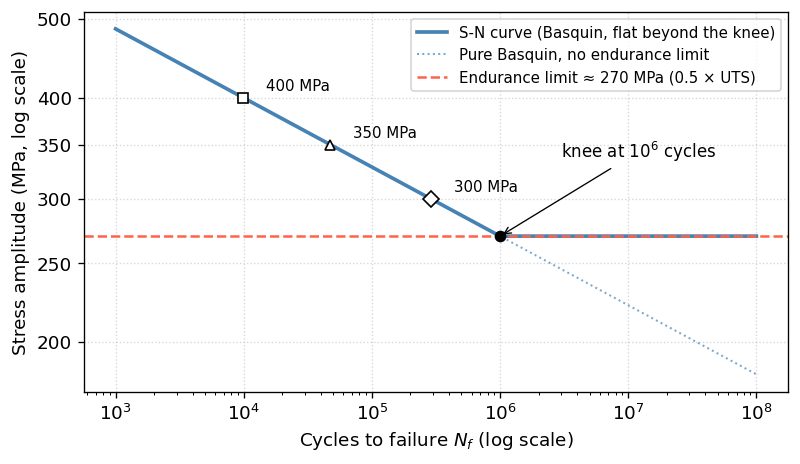

σa = 400 MPa  →  Nf ≈ 9.86e+03 cycles
σa = 350 MPa  →  Nf ≈ 4.74e+04 cycles
σa = 300 MPa  →  Nf ≈ 2.90e+05 cycles


In [4]:
# Sweep a range of lives and read off the stress amplitude each one implies.
Nf = np.logspace(3, 8, 200)                    # cycles to failure, 10^3 ... 10^8
sigma_a = basquin_stress(Nf)                   # MPa
endurance_limit = ENDURANCE_FRACTION * SIGMA_UTS   # MPa
N_knee = cycles_to_failure(endurance_limit)    # life where Basquin meets the limit

# A steel S-N curve follows Basquin down to the knee, then runs flat at the
# endurance limit. The pure-Basquin continuation is drawn faint and dotted: it is
# the conservative no-endurance-limit assumption used in the Miner's rule section.
sigma_steel = np.maximum(sigma_a, endurance_limit)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.loglog(Nf, sigma_steel, 'steelblue', lw=2.2, label="S-N curve (Basquin, flat beyond the knee)")
ax.loglog(Nf[Nf > N_knee], sigma_a[Nf > N_knee], color='steelblue', lw=1.2,
          linestyle=':', alpha=0.7, label="Pure Basquin, no endurance limit")
ax.axhline(endurance_limit, color='tomato', lw=1.5, linestyle='--',
           label=f"Endurance limit ≈ {endurance_limit:.0f} MPa (0.5 × UTS)")
ax.plot([N_knee], [endurance_limit], 'ko', ms=6)
ax.annotate("knee at $10^6$ cycles", xy=(N_knee, endurance_limit),
            xytext=(N_knee * 3, endurance_limit * 1.25),
            arrowprops=dict(arrowstyle='->', lw=0.8), fontsize=10)
# the three load blocks of the chapter's Miner example, read off the line
for sa, mk in ((400, 's'), (350, '^'), (300, 'D')):
    ax.plot([cycles_to_failure(sa)], [sa], mk, color='black', mfc='white', ms=6.5, zorder=4)
    ax.annotate(f"{sa} MPa", xy=(cycles_to_failure(sa), sa),
                xytext=(cycles_to_failure(sa) * 1.5, sa * 1.02), fontsize=9)
ax.set_xlabel("Cycles to failure $N_f$ (log scale)"); ax.set_ylabel("Stress amplitude (MPa, log scale)")
ax.legend(fontsize=9)
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter
yt = [200, 250, 300, 350, 400, 500]
ax.yaxis.set_major_locator(FixedLocator(yt)); ax.yaxis.set_major_formatter(FixedFormatter([str(v) for v in yt]))
ax.yaxis.set_minor_formatter(NullFormatter()); ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / 'fig20_nb1_sn_curve_basquin.png', bbox_inches='tight', dpi=300)
plt.show()

# Invert the law: what life does each measured stress amplitude predict?
for sa in [400, 350, 300]:
    print(f"σa = {sa} MPa  →  Nf ≈ {cycles_to_failure(sa):.2e} cycles")

---
## 2 — Miner's Rule — Cumulative Damage

Palmgren-Miner's rule states that the total fatigue damage D is the sum of fractional damages at each amplitude level: D = Σ(n_i / N_f,i), where n_i is the number of cycles applied at stress amplitude σ_i and N_f,i is the life at that amplitude from the S-N curve. Failure is predicted when D reaches 1.0.

The rule has well-known limitations — it ignores sequence effects, crack closure, and mean stress — but it remains the starting point for any service-life assessment from a measured load spectrum. In practice, strain gages feed load data to a rainflow cycle-counting algorithm, which sorts cycles by amplitude and mean stress; Miner's rule then converts that sorted count into a damage fraction. The table below repeats the chapter's worked example: three blocks a year at 400, 350 and 300 MPa. Most of the damage comes from the lowest block, because it has the most cycles. The second table shows how sensitive the total is to the measured amplitude: with an S-N slope of about 1/11.75, a gage that reads 5% low hides three-quarters more damage in each block.

We reuse `cycles_to_failure` from above for every N_f,i, applying Basquin's law at *all* amplitude levels — including those at or below the endurance limit. That is the conservative choice: it credits no infinite-life threshold, so even small cycles contribute a little damage.

In [5]:
# The chapter's three blocks: (stress amplitude in MPa, applied cycles n per year).
spectrum = [(400, 1_000), (350, 10_000), (300, 100_000)]

total_D = 0.0
print(f"{'σa':>8}  {'n':>8}  {'Nf':>14}  {'n/Nf':>10}  {'D':>10}")
print("-" * 54)
for sigma_a, n in spectrum:
    Nf = cycles_to_failure(sigma_a)
    d = n / Nf
    total_D += d
    print(f"{sigma_a:>8}  {n:>8,}  {Nf:>14.2e}  {d:>10.5f}  {total_D:>10.5f}")

status = "FAILED" if total_D >= 1 else f"{(1 - total_D) * 100:.1f}% life remaining"
print(f"Total D = {total_D:.4f}  ({status})")

# Sensitivity to the measured amplitude: what if the gage read 5% low?
k = -1.0 / B_EXPONENT
print(f"\nS-N slope k = {k:.2f};  1.05**k = {1.05 ** k:.2f}")
D_300 = sum(n / cycles_to_failure(sa * (1.05 if sa == 300 else 1.0)) for sa, n in spectrum)
D_all = sum(n / cycles_to_failure(sa * 1.05) for sa, n in spectrum)
print(f"300 MPa block 5% low:  true D = {D_300:.2f}")
print(f"all blocks 5% low:     true D = {D_all:.2f}")


      σa         n              Nf        n/Nf           D
------------------------------------------------------
     400     1,000        9.86e+03     0.10140     0.10140
     350    10,000        4.74e+04     0.21111     0.31252
     300   100,000        2.90e+05     0.34494     0.65746
Total D = 0.6575  (34.3% life remaining)

S-N slope k = 11.75;  1.05**k = 1.77
300 MPa block 5% low:  true D = 0.92
all blocks 5% low:     true D = 1.17


---
## Where to take this next

- **Add a mean-stress correction.** Real spectra are rarely fully reversed. Apply the Goodman relation from the chapter (Eq. 20.1), $\sigma_a/\sigma_e + \sigma_m/\sigma_{UTS} = 1$, to convert each level's (amplitude, mean) pair into an equivalent fully reversed amplitude *before* calling `cycles_to_failure`, and watch the damage total climb.
- **Enforce a true endurance limit.** Modify `cycles_to_failure` to return infinite life (zero damage) below `endurance_limit`, then re-run Miner's rule. Compare the total against the pure-Basquin result here — the difference is exactly what the "infinite-life" design philosophy buys you.
- **Close the loop with real data.** Replace the hand-written `spectrum` with the output of a rainflow cycle-counting algorithm (Chapter 33; applied in Chapter 37) applied to a measured or simulated strain-time history. That is the full pipeline: strain gage → rainflow histogram → S-N curve → Miner's rule → predicted life.